<h2>Exercise 04: Histogram</h2>

In [1]:
import pandas as pd 
import sqlite3
import matplotlib.pyplot as plt

### Preprocessing

In [2]:
conn = sqlite3.connect("../data/checking-logs.sqlite")

In [3]:
df = pd.io.sql.read_sql(
    """
    SELECT 
        *
    FROM checker
    WHERE uid LIKE "user_%"
    """,
    conn,
    parse_dates=["timestamp"]
)

df

,index,status,success,timestamp,numTrials,labname,uid
0,7,ready,0,2020-04-17 05:19:02.744528,1,project1,user_4
1,8,checking,0,2020-04-17 05:22:35.249331,2,project1,user_4
2,9,ready,1,2020-04-17 05:22:45.549397,2,project1,user_4
3,10,checking,1,2020-04-17 05:34:14.691200,3,project1,user_4
4,11,ready,1,2020-04-17 05:34:24.422370,3,project1,user_4
...,...,...,...,...,...,...,...
3202,3397,ready,0,2020-05-21 20:19:06.872761,7,laba06s,user_1
3203,3398,checking,0,2020-05-21 20:22:41.785725,8,laba06s,user_1
3204,3399,ready,0,2020-05-21 20:22:41.877806,8,laba06s,user_1
3205,3400,checking,0,2020-05-21 20:37:00.129678,9,laba06s,user_1


In [4]:
df["date"] = df["timestamp"].dt.date
df["weekday"] = df["timestamp"].dt.weekday
df["hour"] = df["timestamp"].dt.hour


df["day_type"] = df["weekday"].apply(
    lambda x: "working" if x < 5 else "weekend"
)

df

,index,status,success,timestamp,numTrials,labname,uid,date,weekday,hour,day_type
0,7,ready,0,2020-04-17 05:19:02.744528,1,project1,user_4,2020-04-17,4,5,working
1,8,checking,0,2020-04-17 05:22:35.249331,2,project1,user_4,2020-04-17,4,5,working
2,9,ready,1,2020-04-17 05:22:45.549397,2,project1,user_4,2020-04-17,4,5,working
3,10,checking,1,2020-04-17 05:34:14.691200,3,project1,user_4,2020-04-17,4,5,working
4,11,ready,1,2020-04-17 05:34:24.422370,3,project1,user_4,2020-04-17,4,5,working
...,...,...,...,...,...,...,...,...,...,...,...
3202,3397,ready,0,2020-05-21 20:19:06.872761,7,laba06s,user_1,2020-05-21,3,20,working
3203,3398,checking,0,2020-05-21 20:22:41.785725,8,laba06s,user_1,2020-05-21,3,20,working
3204,3399,ready,0,2020-05-21 20:22:41.877806,8,laba06s,user_1,2020-05-21,3,20,working
3205,3400,checking,0,2020-05-21 20:37:00.129678,9,laba06s,user_1,2020-05-21,3,20,working


In [5]:
df["is_weekend"] = df["timestamp"].dt.weekday.isin([5, 6])
df["hour"] = df["timestamp"].dt.hour
df.rename(columns={"timestamp": "date"}, inplace=True)
# df["date"] = df["date"].dt.date
df

,index,status,success,date,numTrials,labname,uid,date,weekday,hour,day_type,is_weekend
0,7,ready,0,2020-04-17 05:19:02.744528,1,project1,user_4,2020-04-17,4,5,working,False
1,8,checking,0,2020-04-17 05:22:35.249331,2,project1,user_4,2020-04-17,4,5,working,False
2,9,ready,1,2020-04-17 05:22:45.549397,2,project1,user_4,2020-04-17,4,5,working,False
3,10,checking,1,2020-04-17 05:34:14.691200,3,project1,user_4,2020-04-17,4,5,working,False
4,11,ready,1,2020-04-17 05:34:24.422370,3,project1,user_4,2020-04-17,4,5,working,False
...,...,...,...,...,...,...,...,...,...,...,...,...
3202,3397,ready,0,2020-05-21 20:19:06.872761,7,laba06s,user_1,2020-05-21,3,20,working,False
3203,3398,checking,0,2020-05-21 20:22:41.785725,8,laba06s,user_1,2020-05-21,3,20,working,False
3204,3399,ready,0,2020-05-21 20:22:41.877806,8,laba06s,user_1,2020-05-21,3,20,working,False
3205,3400,checking,0,2020-05-21 20:37:00.129678,9,laba06s,user_1,2020-05-21,3,20,working,False


In [6]:
def get_abs(df):
    grouped = df.groupby(["date", "hour"])["uid"].count().reset_index()
    return grouped.groupby("hour")["uid"].sum()

In [7]:
df_working = df[df["is_weekend"]==False]
df_weekday = df[df["is_weekend"]==True]

In [8]:
df_weekday = df[df["is_weekend"]==True]["hour"]
df_working = df[df["is_weekend"]==False]["hour"]

In [9]:
df_weekday.value_counts()

hour
11    118
20    117
15    114
13    108
19    105
14     87
16     74
21     72
18     68
22     59
12     57
17     50
23     32
10     28
8      28
9      22
7      16
0       6
1       6
5       2
3       1
Name: count, dtype: int64

In [10]:
df_working.value_counts()

hour
21    292
19    214
17    192
20    183
16    170
18    167
15    141
10    132
14    122
11     88
12     79
13     73
22     45
8      37
7      31
9      30
5      15
23     15
0       6
6       3
3       2
Name: count, dtype: int64

### Result

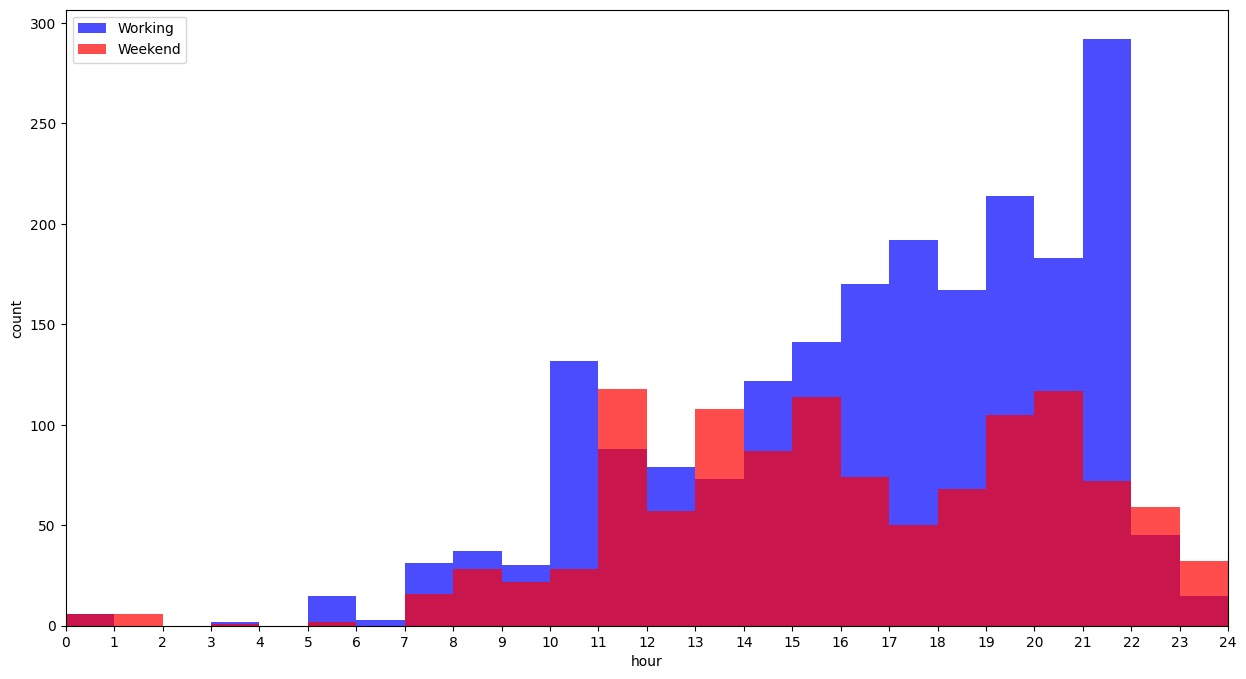

In [11]:
fig, ax = plt.subplots(figsize=(15, 8))

df_working.plot(
    kind='hist',
    ax=ax,
    bins=24,
    range=(0, 24),
    label='Working',
    color='blue',
    alpha=0.7
)

df_weekday.plot(
    kind='hist',
    ax=ax,
    bins=24,
    range=(0, 24),
    label='Weekend',
    color='red',
    alpha=0.7
)

ax.set_xlim(0, 24)
ax.set_xticks(range(25))
ax.legend(loc='upper left')
ax.set_ylabel('count')
ax.set_xlabel('hour')
plt.show()

<h2>Answer: 0, 1, 11, 13, 22, 23</h2>

In [12]:
conn.close()